## HateXplain - 2 OBJECTIVES

### Multi Task Learning

* **Dataset:** HateXplain
* **Task :** Classification
* **Target 1:** Hate speech
* **Target 2:** Hate speech against woman

### Methods

* **MOLA**
* **Random Weights**

### Preparation 

In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import random
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from transformers import AutoTokenizer
from transformers import AutoModel
from collections import Counter
from tqdm import tqdm
from datasets import load_dataset


/home/lineccsa/mestrado/moo_research/moo_env/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [3]:
from ml_moo import moo, get_objectives, MooScalarization
from ml_moo.analysis.metrics import compute_hypervolume_progress
from ml_moo.analysis.visualization import plot_pareto_2d, plot_multiple_hypervolumes, plot_hypervolume
from ml_moo.scalarization.two_objs_hate_speech_group import HateSpeechScalarization

In [4]:
# Definir seed para reprodutibilidade
def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True

set_seed()

## Dataset and Model

In [5]:
# Carregar o dataset HateXplain
dataset = load_dataset("Hate-speech-CNERG/hatexplain", trust_remote_code=True)


In [6]:
# model_name = "tum-nlp/bert-hateXplain"
#"hate-bert, uncased bert"
model_name="bert-base-uncased"

In [7]:
print("GPU disponível:", torch.cuda.is_available())

GPU disponível: True


In [8]:
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")

In [9]:
def extract_bert_embeddings(dataset, tokenizer_name="bert-base-uncased", max_length=128, batch_size=32, device="cuda"):
    tokenizer = AutoTokenizer.from_pretrained(tokenizer_name)
    model = AutoModel.from_pretrained(tokenizer_name).to(device)
    model.eval()

    texts = [" ".join(d["post_tokens"]) for d in dataset]

    embeddings = []
    with torch.no_grad():
        for i in tqdm(range(0, len(texts), batch_size)):
            batch_texts = texts[i:i+batch_size]
            encoding = tokenizer(
                batch_texts,
                padding=True,
                truncation=True,
                max_length=max_length,
                return_tensors="pt"
            ).to(device)

            outputs = model(**encoding)
            cls_embeddings = outputs.last_hidden_state[:, 0, :]  # CLS token
            embeddings.append(cls_embeddings.cpu())

    return torch.cat(embeddings, dim=0)  # Shape: (N, hidden_size)

In [10]:
from sklearn.decomposition import PCA
from collections import Counter
from torch.utils.data import Dataset

def apply_pca_and_save(embeddings: torch.Tensor, n_components=50, output_path="embeddings_pca.npy"):
    pca = PCA(n_components=n_components)
    reduced = pca.fit_transform(embeddings.numpy())
    np.save(output_path, reduced)
    return reduced

class PCAEmbeddingsDataset(Dataset):
    def __init__(self, pca_embeddings: np.ndarray, raw_dataset):
        self.embeddings = torch.tensor(pca_embeddings, dtype=torch.float)
        self.raw_dataset = raw_dataset
        

    def __len__(self):
        return len(self.embeddings)

    def __getitem__(self, idx):
        data = self.raw_dataset[idx]

        # Encontrar a moda dos rótulos (classificação de discurso de ódio)
        labels = data["annotators"]["label"]
        label_counts = Counter(labels)
        majority_label = label_counts.most_common(1)[0][0]  # Pega a moda
      
        label_hate = 0 if majority_label == 1 else 1

        # Criar rótulo para discurso de ódio contra gênero (exemplo: "women")
        target_groups = data["annotators"]["target"]
        #label_target = 1 if len(target_groups) > 0 else 0
        count_gender = 0

        for i in range(len(target_groups)):
            if ('Women' in target_groups[i] or 'Homosexual' in target_groups[i]):
                count_gender += 1

        target_hate = 1 if ((count_gender > 0) and (label_hate == 1)) else 0  # 1 se houver ataque a mulheres, 0 caso contrário

        return {
            "embedding": self.embeddings[idx],
            "label": torch.tensor(label_hate, dtype=torch.long),
            "target_hate": torch.tensor(target_hate, dtype=torch.long),
        }


In [11]:
# Suponha que você tenha carregado seu dataset JSON como `raw_dataset`

embeddings = extract_bert_embeddings(dataset["train"])
pca_embeddings = apply_pca_and_save(embeddings, n_components=50, output_path="embeddings_pca.npy")
#
## Agora use para treinar seu modelo
dataset_pca = PCAEmbeddingsDataset(pca_embeddings, dataset["train"])
train_dataloader = DataLoader(dataset_pca, batch_size=64, shuffle=True)

100%|██████████| 481/481 [00:47<00:00, 10.06it/s]


In [12]:
class MultiTaskHateSpeechDataset(Dataset):
    def __init__(self, dataset, tokenizer_name="bert-base-uncased", max_length=128):
        self.dataset = dataset
        self.tokenizer = AutoTokenizer.from_pretrained(tokenizer_name)
        self.max_length = max_length
        self.bert_model = AutoModel.from_pretrained(tokenizer_name)
        self.bert_model.eval()

    def __len__(self):
        return len(self.dataset)

    def __getitem__(self, idx):
        data = self.dataset[idx]

        # Converter lista de tokens em texto
        text = " ".join(data["post_tokens"])

        # Encontrar a moda dos rótulos (classificação de discurso de ódio)
        labels = data["annotators"]["label"]
        label_counts = Counter(labels)
        majority_label = label_counts.most_common(1)[0][0]  # Pega a moda
      
        label_hate = 0 if majority_label == 1 else 1

        # Criar rótulo para discurso de ódio contra gênero (exemplo: "women")
        target_groups = data["annotators"]["target"]
        #label_target = 1 if len(target_groups) > 0 else 0
        count_gender = 0
        count_race = 0

        for i in range(len(target_groups)):
            if ('Women' in target_groups[i] or 'Homosexual' in target_groups[i]):
                count_gender += 1

        gender_hate = 1 if ((count_gender > 0) and (label_hate == 1)) else 0  # 1 se houver ataque a mulheres, 0 caso contrário
        target_hate = 1 if ((count_race > 0) and (label_hate == 1)) else 0

        # Tokenizar texto
        encoding = self.tokenizer(
            text,
            padding="max_length",
            truncation=True,
            max_length=self.max_length,
            return_tensors="pt"
        )

        return {
            "input_ids": encoding["input_ids"].squeeze(),
            "attention_mask": encoding["attention_mask"].squeeze(),
            "label": torch.tensor(label_hate, dtype=torch.long),
            "target_hate": torch.tensor(target_hate, dtype=torch.long),
        }

In [13]:
# Criar os datasets para treino, validação e teste
# train_dataset = MultiTaskHateSpeechDataset(dataset["train"])
# val_dataset = MultiTaskHateSpeechDataset(dataset["train"])
# test_dataset = MultiTaskHateSpeechDataset(dataset["train"])
# 
# # DataLoaders
# batch_size = 8
# train_dataloader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
# valid_dataloader = DataLoader(val_dataset, batch_size=batch_size)
# test_dataloader = DataLoader(test_dataset, batch_size=batch_size)

In [14]:
opt_params = {
    'node_time_limit': 2,
    'target_size': 50,
    'target_gap': 0,
    'node_gap': 0.05,
    'norm': False
}
results = {}

## MOLA

15:47:43 | DEBUG | ml_moo | Filtered parameters for Mola: {'node_time_limit': 2, 'target_size': 50, 'target_gap': 0, 'node_gap': 0.05, 'norm': False}
15:47:43 | DEBUG | ml_moo | Finding 1th individual minimum


device: cuda:0
available: True


Epoch 1/3 - Training: 100%|██████████| 241/241 [00:02<00:00, 112.45it/s]


Epoch 1 - Average training loss: 0.3517


Epoch 2/3 - Training: 100%|██████████| 241/241 [00:02<00:00, 117.26it/s]


...

Epoch 2 - Average training loss: 0.2876


Epoch 3/3 - Training: 100%|██████████| 241/241 [00:01<00:00, 131.78it/s]


Epoch 3 - Average training loss: 0.2890


Evaluating: 100%|██████████| 241/241 [00:01<00:00, 148.77it/s]
19:58:05 | DEBUG | ml_moo | Calculated weights: [0.76310442 0.23689558]
19:58:05 | DEBUG | ml_moo | Importance: 5.569736097899014e-05
19:58:05 | DEBUG | ml_moo | Global lower bound (y*): [0.58855975 0.45255676]
19:58:05 | DEBUG | ml_moo | Iteration 2001
19:58:05 | DEBUG | ml_moo | Solutions list: [array([0.58871316, 0.45299137]), array([0.58876941, 0.45298774]), array([0.58868683, 0.45303256]), array([0.58868326, 0.45308917]), array([0.58883587, 0.45289722]), array([0.58888249, 0.45263998]), array([0.58865938, 0.45312204]), array([0.58859668, 0.45332322]), array([0.58855975, 0.45361067]), array([0.58946185, 0.45255676]), array([0.58903959, 0.45260253])]


new solution dominated [0.58952557 0.45300009]


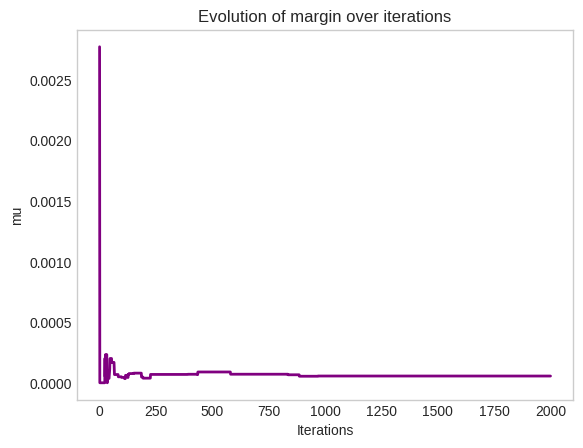

19:58:05 | INFO | ml_moo | Fit runtime: 15022.40 seconds


In [15]:
method = 'mola'
w_scalar = HateSpeechScalarization(train_dataloader=train_dataloader, device=device, model_name=model_name)
moopt = moo(w_scalar).mo_optimization(method, **opt_params)
objs = get_objectives(moopt)
#hypervolume_values = compute_hypervolume_progress(objs)
hypervolume_values = moopt.get_hypervolumes()
results[method] = {
                "moopt": moopt,
                "objectives": objs,
                "models": moopt.get_models() if hasattr(moopt, "get_models") else None,
                "hypervolume": hypervolume_values
            }

630 min - 12 soluções - 300 iterações
86 min 11 s - 12 soluções - 50 iterações

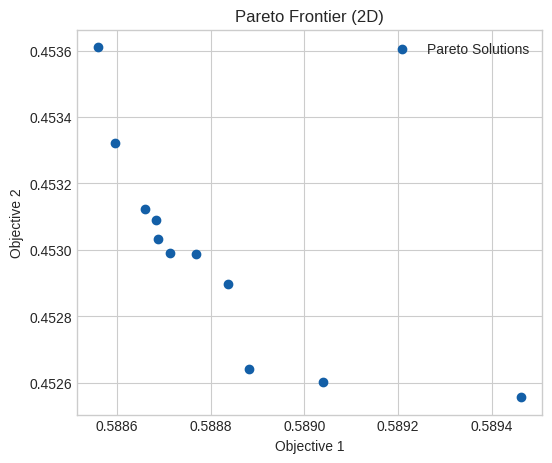

In [16]:
plot_pareto_2d(objs)

## Random Weight

90 min 41 s - 50 iteraçoes

In [17]:
method = 'random_weight'
w_scalar = HateSpeechScalarization(train_dataloader=train_dataloader, device=device, model_name=model_name)
moopt = moo(w_scalar).mo_optimization(method, **opt_params)
objs = get_objectives(moopt)
hypervolume_values = compute_hypervolume_progress(objs)
results[method] = {
                "moopt": moopt,
                "objectives": objs,
                "models": moopt.get_models() if hasattr(moopt, "get_models") else None,
                "hypervolume": hypervolume_values
            }

19:58:06 | WARNING | ml_moo | Ignored parameters for random_weights: {'targetGap', 'nodeTimeLimit', 'nodeGap'}
19:58:06 | DEBUG | ml_moo | Filtered parameters for random_weights: {'targetSize': 50, 'norm': False}
19:58:06 | DEBUG | ml_moo.moo.random_weights | Finding 1th individual minima


device: cuda:0
available: True


Epoch 1/3 - Training: 100%|██████████| 241/241 [00:01<00:00, 132.85it/s]


Epoch 1 - Average training loss: 0.3466


Epoch 2/3 - Training: 100%|██████████| 241/241 [00:01<00:00, 133.09it/s]


...

Epoch 1 - Average training loss: 0.2671


Epoch 2/3 - Training: 100%|██████████| 241/241 [00:01<00:00, 132.81it/s]


Epoch 2 - Average training loss: 0.2668


Epoch 3/3 - Training:  13%|█▎        | 32/241 [00:00<00:01, 131.50it/s]


KeyboardInterrupt: 

## Comparison between MOO methods

In [ ]:
from ml_moo.tests.experiments.run import run_experiments
from ml_moo.analysis.moo_analyzer import Analyzer

In [ ]:
pareto_dict = {
        method: res["objectives"]
        for method, res in results.items()
        if "objectives" in res
    }

hypervolumes_dict = {
        method: res["hypervolume"]
        for method, res in results.items()
        if "hypervolume" in res
    }

Analyzer.run_multiple(pareto_dict = pareto_dict,
                      hypervolumes_values = hypervolumes_dict,
                      show_pareto = True, 
                      show_hypervolume = True,
                      subplots = True,
                      subplots_hv = True,
                      )